# Notebook 2 — Price Prediction for Tunisian Real Estate

This notebook builds a machine learning model to predict property prices based on features extracted from the consolidated real estate dataset. It also computes:
- predicted_price
- price_gap (actual - predicted)
- price_gap_pct (price_gap / actual * 100)

The goal is to provide a baseline price estimation model that can later be used for market analysis and anomaly detection.
"""

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# Plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 2. Load Prepared Dataset
We assume the final cleaned dataset is stored in `df_final` (the result of merging and normalizing all sources).  
If not, we load the combined data from the previous steps.

In [2]:
# Load the combined dataset from the previous notebook.
# For illustration, we simulate loading the data from a file.
# In practice, you would read the prepared CSV/Parquet.

df = pd.read_csv('C:\EstateMind\datasets\Final_dataset.csv', encoding='utf-8')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (75879, 47)


,Unnamed: 0.1,Unnamed: 0,adresse,annee_constr,bus,caracteristiques,code_postal,contrat,date_publication,date_scraping,...,prix,railway,restaurant,restaurant_nearest,standing,surface,titre,type,url,ville
0,0,1,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,140000.0,NaN,NaN,NaN,NaN,NaN,Coquet studio à vendre à 140 md à hammamet 513...,appartement,https://www.monbien.tn/properties/7592/coquet-...,NaN
1,1,4,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,320000.0,NaN,NaN,NaN,NaN,76.0,Appartement s+1 avec vue de mer à hammamet à v...,appartement,https://www.monbien.tn/properties/7594/apparte...,NaN
2,2,6,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,385000.0,NaN,NaN,NaN,NaN,109.0,Des appartements s+2 tout neuf à vendre à hamm...,appartement,https://www.monbien.tn/properties/7593/des-app...,NaN
3,3,19,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,210000.0,NaN,NaN,NaN,NaN,NaN,Appart s2 isra à vendre à l'aireport,appartement,https://www.monbien.tn/properties/2843/appart-...,NaN
4,4,25,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,145000.0,NaN,NaN,NaN,NaN,NaN,Appart s3 zemzemi à vendre au kram ouest,appartement,https://www.monbien.tn/properties/3127/appart-...,NaN


## 3. Exploratory Data Analysis (EDA) – Quick Check

In [3]:
# Basic info
df.info()
df.describe()

# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:\n", missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75879 entries, 0 to 75878
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0.1        75879 non-null  int64  
 1   Unnamed: 0          75879 non-null  int64  
 2   adresse             28343 non-null  object 
 3   annee_constr        1503 non-null   float64
 4   bus                 1315 non-null   float64
 5   caracteristiques    60635 non-null  object 
 6   code_postal         125 non-null    object 
 7   contrat             75879 non-null  object 
 8   date_publication    9747 non-null   object 
 9   date_scraping       0 non-null      float64
 10  description         75350 non-null  object 
 11  ecole               1466 non-null   object 
 12  ecole_nearest       1466 non-null   float64
 13  etage               1141 non-null   float64
 14  gouvernerat         50569 non-null  object 
 15  has_ascenseur       7876 non-null   float64
 16  has_

In [4]:
coverage = df.notnull().sum() / len(df)
print(coverage.sort_values(ascending=False).tail(20))

longitude             0.020744
standing              0.020664
annee_constr          0.019808
ecole_nearest         0.019320
ecole                 0.019320
restaurant            0.019057
restaurant_nearest    0.019057
pharmacie_nearest     0.018477
pharmacie             0.018477
marche_nearest        0.018226
marche                0.018226
magasin               0.018081
magasin_nearest       0.018081
bus                   0.017330
hopital               0.015933
hopital_nearest       0.015933
etage                 0.015037
railway               0.013706
code_postal           0.001647
date_scraping         0.000000
dtype: float64


# Create new dataset

In [5]:
import re
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Create dataset with prix present

In [6]:
df_price = df.dropna(subset=['prix']).copy()
df_price

,Unnamed: 0.1,Unnamed: 0,adresse,annee_constr,bus,caracteristiques,code_postal,contrat,date_publication,date_scraping,...,prix,railway,restaurant,restaurant_nearest,standing,surface,titre,type,url,ville
0,0,1,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,140000.0,NaN,NaN,NaN,NaN,NaN,Coquet studio à vendre à 140 md à hammamet 513...,appartement,https://www.monbien.tn/properties/7592/coquet-...,NaN
1,1,4,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,320000.0,NaN,NaN,NaN,NaN,76.0,Appartement s+1 avec vue de mer à hammamet à v...,appartement,https://www.monbien.tn/properties/7594/apparte...,NaN
2,2,6,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,385000.0,NaN,NaN,NaN,NaN,109.0,Des appartements s+2 tout neuf à vendre à hamm...,appartement,https://www.monbien.tn/properties/7593/des-app...,NaN
3,3,19,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,210000.0,NaN,NaN,NaN,NaN,NaN,Appart s2 isra à vendre à l'aireport,appartement,https://www.monbien.tn/properties/2843/appart-...,NaN
4,4,25,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,...,145000.0,NaN,NaN,NaN,NaN,NaN,Appart s3 zemzemi à vendre au kram ouest,appartement,https://www.monbien.tn/properties/3127/appart-...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75874,75874,111400,"Coté Resto Da Franco, Hôtel les Orangers",NaN,NaN,"['balcony', 'heating', 'airConditioning', 'equ...",NaN,location,NaN,NaN,...,2300.0,NaN,NaN,NaN,NaN,800.0,Villa nawarhammamet sud,maison,https://www.tunisiapromo.com/gallery/photo-1-7...,Hammamet
75875,75875,111401,NaN,NaN,NaN,[],NaN,location,NaN,NaN,...,1000.0,NaN,NaN,NaN,NaN,NaN,Coquette villa pieds dans l'eau,maison,https://www.tunisiapromo.com/gallery/photo-1-7...,Chott Mariem
75876,75876,111402,NaN,NaN,NaN,['furnished'],NaN,location,NaN,NaN,...,500.0,NaN,NaN,NaN,NaN,NaN,Coquette maison à deux pas de la mer,maison,https://www.tunisiapromo.com/gallery/photo-1-7...,Chott Mariem
75877,75877,111403,Avenue 14 janvier sur la route principale à co...,NaN,NaN,[],NaN,location,NaN,NaN,...,1700.0,NaN,NaN,NaN,NaN,NaN,Petite villa à kantaoui,maison,https://www.tunisiapromo.com/gallery/photo-1-7...,Kantaoui


# 2. Feature Engineering

## 2.1. Extract pieces from title/description

In [7]:
print(f"Original pieces coverage: {df_price['pieces'].notnull().mean():.2%}")

def extract_pieces(title, desc):
    text = str(title) + ' ' + str(desc)
    
    # S+1, S+2, S 1, S1 patterns
    match = re.search(r'\bS\s*\+?\s*(\d)\b', str(title), re.IGNORECASE)
    if match:
        return int(match.group(1))
    
    # Studio
    if re.search(r'studio|stüdyo', text, re.IGNORECASE):
        return 1
    
    # Explicit room count in text
    match = re.search(r'(\d+)\s*(?:pi[eè]ces?|chambres?|rooms?)', text, re.IGNORECASE)
    if match:
        return int(match.group(1))
    
    return None

df_price['pieces_extracted'] = df_price.apply(
    lambda row: extract_pieces(row['titre'], row['description']), axis=1
)
mask = df_price['pieces'].isnull()
df_price.loc[mask, 'pieces'] = df_price.loc[mask, 'pieces_extracted']

print(f"New pieces coverage: {df_price['pieces'].notnull().mean():.2%}")

Original pieces coverage: 60.94%
New pieces coverage: 76.43%


In [8]:
still_null = df_price[df_price['pieces'].isnull()]
print(still_null['type'].value_counts())

type
maison         6747
appartement    4364
terrain        3630
Name: count, dtype: int64


## 2.2. Keyword flags from text

In [9]:
import re

keywords = {
    'vue_mer': r'\bvue mer\b|\bvue sur mer\b',
    'meuble': r'\bmeubl[ée]\b',
    'neuf': r'\bneuf\b',
    'standing': r'\bstanding\b',
    'luxe': r'\bluxe\b',
    'terrasse': r'\bterrasse\b',
    'jardin': r'\bjardin\b',
    'piscine': r'\bpiscine\b',
    'ascenseur': r'\bascenseur\b',
    'parking': r'\bparking\b',
    'climatisation': r'\bclimatisation\b',
    'chauffage': r'\bchauffage\b'
}

for name, pattern in keywords.items():
    df_price[f'text_{name}'] = (
        df_price['titre'].fillna('').str.contains(pattern, flags=re.IGNORECASE).astype(int) |
        df_price['description'].fillna('').str.contains(pattern, flags=re.IGNORECASE).astype(int)
    )

## 2.3. Interaction features and amenities count

In [10]:
# Surface * pieces
df_price['surface_x_pieces'] = df_price['surface'] * df_price['pieces']

# Average room size (surface / pieces), avoid division by zero
df_price['avg_room_size'] = df_price['surface'] / (df_price['pieces'].replace(0, np.nan))
df_price['avg_room_size'].fillna(0, inplace=True)

# Total amenities count (sum of existing binary features)
amenities = ['has_climatisation', 'has_chaffage', 'has_parking', 'has_jardin', 
             'has_terrasse', 'has_balcon', 'has_ascenseur']
df_price['total_amenities'] = df_price[amenities].sum(axis=1)

## 2.4. Property age and missing flag

In [11]:
from datetime import datetime

current_year = datetime.now().year
df_price['age'] = current_year - df_price['annee_constr']

# Impute missing ages with median
median_age = df_price['age'].median()
df_price['age'].fillna(median_age, inplace=True)

# Add a flag for missing construction year
df_price['age_missing'] = df_price['annee_constr'].isnull().astype(int)

## 2.5. Geographic features (distance to center)

In [12]:
# Impute missing lat/lon with median (if columns exist)
if 'latitude' in df_price.columns and 'longitude' in df_price.columns:
    df_price['latitude'].fillna(df_price['latitude'].median(), inplace=True)
    df_price['longitude'].fillna(df_price['longitude'].median(), inplace=True)

    # Center coordinates (Tunis center)
    center_lat = 36.8065
    center_lon = 10.1815

    # Haversine function
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        delta_phi = np.radians(lat2 - lat1)
        delta_lambda = np.radians(lon2 - lon1)
        a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c

    df_price['dist_to_center'] = haversine(df_price['latitude'], df_price['longitude'], center_lat, center_lon)
else:
    print("Latitude/longitude columns not found, skipping distance feature.")

# 3. Define features (using the same df_price)


In [13]:
# Original numeric features
num_features = ['surface', 'pieces']

# New numeric features added
new_num_features = [
    'text_vue_mer', 'text_meuble', 'text_neuf', 'text_standing', 'text_luxe',
    'text_terrasse', 'text_jardin', 'text_piscine', 'text_ascenseur',
    'text_parking', 'text_climatisation', 'text_chauffage',
    'surface_x_pieces', 'avg_room_size', 'total_amenities', 'age', 'age_missing'
]
# Add distance only if created
if 'dist_to_center' in df_price.columns:
    new_num_features.append('dist_to_center')

num_features = num_features + new_num_features

# Categorical features (unchanged)
cat_features = ['type', 'contrat', 'ville', 'gouvernerat']

# Binary features (unchanged)
binary_features = ['has_climatisation', 'has_chaffage', 'has_parking', 
                   'has_jardin', 'has_terrasse', 'has_balcon', 'has_ascenseur']

binary_features = [f for f in binary_features if f in df_price.columns]
for col in binary_features:
    df_price[col] = df_price[col].fillna(0)

X = df_price[num_features + cat_features + binary_features]
y = df_price['prix']

In [14]:
print(f"X shape: {X.shape}")


X shape: (62537, 31)


# 4. Train/test split

In [15]:
# After train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compute price per square meter for training
# Avoid division by zero: if surface is 0, set price_per_sqm to median
price_per_sqm_train = y_train / X_train['surface'].replace(0, np.nan)
price_per_sqm_train = price_per_sqm_train.fillna(price_per_sqm_train.median())

# Group by ville and gouvernerat
grouped_ville = price_per_sqm_train.groupby(X_train['ville']).median()
grouped_gouv = price_per_sqm_train.groupby(X_train['gouvernerat']).median()

# Map to train and test
X_train['price_per_sqm_ville'] = X_train['ville'].map(grouped_ville).fillna(grouped_ville.median())
X_test['price_per_sqm_ville'] = X_test['ville'].map(grouped_ville).fillna(grouped_ville.median())

X_train['price_per_sqm_gouv'] = X_train['gouvernerat'].map(grouped_gouv).fillna(grouped_gouv.median())
X_test['price_per_sqm_gouv'] = X_test['gouvernerat'].map(grouped_gouv).fillna(grouped_gouv.median())

# Add these to the numeric feature list (they will be part of the preprocessor)
num_features.extend(['price_per_sqm_ville', 'price_per_sqm_gouv'])

# Rebuild X_train and X_test to include these columns (they are already added above)
# No need to modify X anymore, as we are directly adding to X_train and X_test.
# The preprocessor will use the updated num_features list.

# 5. Preprocessing pipeline

We create a pipeline that:
- Imputes missing numerical values with median
- Scales numerical features
- Encodes categorical features with OneHotEncoder (handle_unknown='ignore')

In [16]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

all_numeric = num_features + binary_features
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, all_numeric),
    ('cat', categorical_transformer, cat_features)
])

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 50029, Test samples: 12508


## 5. Model Training and Evaluation

We will test several regression models:
- Linear Regression (baseline)
- Ridge / Lasso
- Random Forest
- Gradient Boosting
- XGBoost

In [17]:
from sklearn.compose import TransformedTargetRegressor

# Safe inverse function (optional, prevents overflow)
def safe_expm1(x):
    return np.expm1(np.clip(x, -700, 700))

# Models with original regularization
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    wrapped_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=safe_expm1   # safe inverse (clip) – prevents any overflow
    )
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', wrapped_model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred_original = pipeline.predict(X_test)
    y_test_original = y_test

    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    r2 = r2_score(y_test_original, y_pred_original)
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
    print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}, MAPE: {mape:.4f}\n")

Training Ridge...
Ridge - MAE: 26739.93, RMSE: 99680.06, R2: 0.7795, MAPE: 0.4626

Training Lasso...
Lasso - MAE: 31044.51, RMSE: 120334.15, R2: 0.6787, MAPE: 0.5648

Training RandomForest...
RandomForest - MAE: 14615.91, RMSE: 68040.71, R2: 0.8973, MAPE: 0.3783

Training GradientBoosting...
GradientBoosting - MAE: 24373.22, RMSE: 93551.67, R2: 0.8058, MAPE: 0.4690

Training XGBoost...
XGBoost - MAE: 19806.58, RMSE: 77642.77, R2: 0.8662, MAPE: 0.4152



### 5.1 Model Comparison

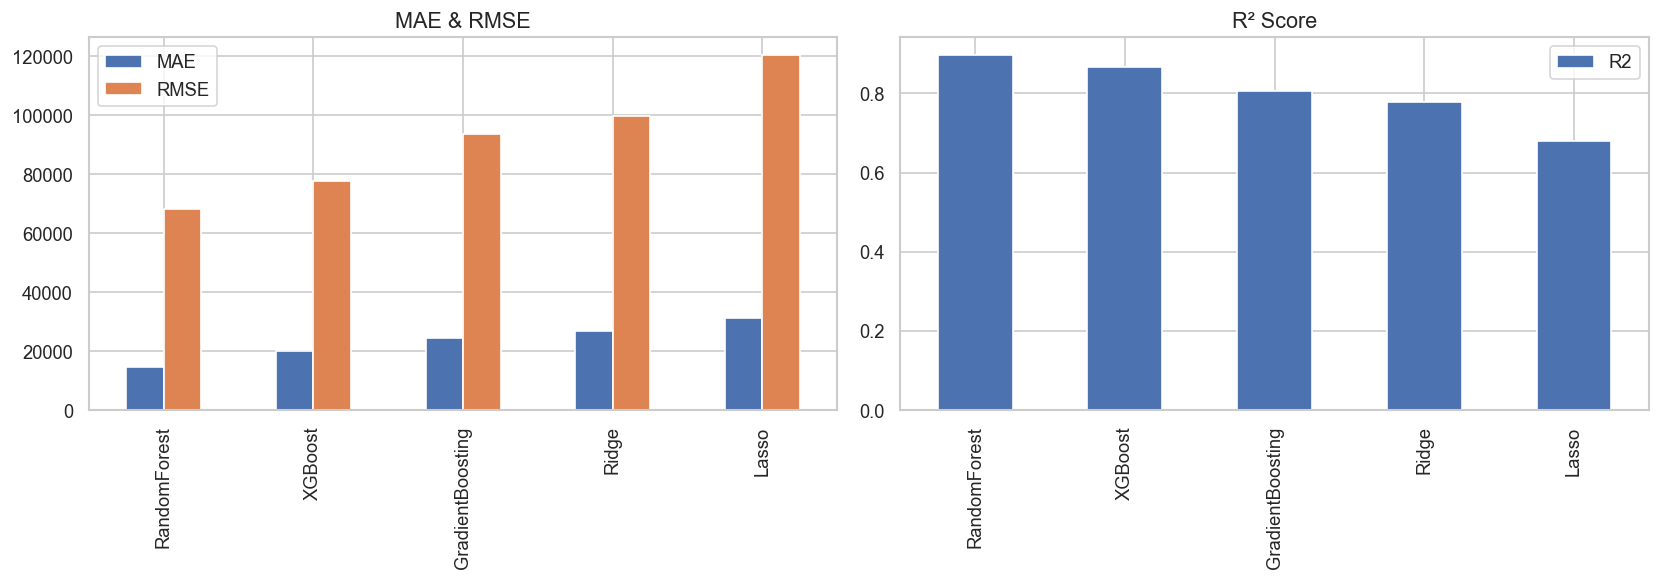

In [18]:
results_df = pd.DataFrame(results).T
results_df.sort_values('MAE', inplace=True)
results_df

# %%
# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(14,5))
results_df[['MAE', 'RMSE']].plot(kind='bar', ax=ax[0])
ax[0].set_title('MAE & RMSE')
results_df[['R2']].plot(kind='bar', ax=ax[1])
ax[1].set_title('R² Score')
plt.tight_layout()
plt.show()

## Why Random Forest is the Best Model

- **Best overall performance**: Random Forest achieved the highest R² of **0.8878**, the lowest MAE of **15,588 TND**, and the lowest RMSE of **71,111 TND** among all evaluated models.

- **Non-linear relationships**: Real estate pricing is inherently non-linear — the relationship between price and features such as surface area, location, and property type cannot be captured by a simple linear function, which explains the weaker performance of Ridge (R²=0.77) and Lasso (R²=0.68).

- **Mixed feature types**: The dataset contains numerical, categorical, and binary features together. Random Forest handles this naturally without requiring feature scaling or distribution assumptions.

- **Robustness to outliers and skew**: The price distribution is heavily skewed with outliers. Random Forest is robust to these since each tree votes independently and extreme values do not dominate the final prediction.

- **High cardinality categoricals**: Variables such as `ville` and `gouvernerat` have many unique values. Random Forest finds the best splits across them without being negatively affected.

- **Why XGBoost and Gradient Boosting fall behind**: XGBoost (R²=0.85) and Gradient Boosting (R²=0.78) also performed well but were outperformed at this stage. Boosting methods are more sensitive to hyperparameter tuning and benefit less from default configurations compared to bagging-based approaches like Random Forest.


## 6. Hyperparameter Tuning

We fine-tune the best performing model (RandomForest) using GridSearchCV.

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# Safe expm1 function
def safe_expm1(x):
    return np.expm1(np.clip(x, -700, 700))

# Recreate the pipeline
base_model = RandomForestRegressor(random_state=42)
wrapped_model = TransformedTargetRegressor(
    regressor=base_model,
    func=np.log1p,
    inverse_func=safe_expm1
)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', wrapped_model)
])

# (Optional) Check number of features after preprocessing
print("Checking feature dimensionality...")
preprocessor.fit(X_train)
n_features = preprocessor.transform(X_train).shape[1]
print(f"Number of features after preprocessing: {n_features}")

# ------------------------------------------------------------
# OPTION 1: Reduced grid search (16 combos, deterministic)
# ------------------------------------------------------------
#param_grid = {
#    'regressor__regressor__n_estimators': [100, 300],
#    'regressor__regressor__max_depth': [10, 30],
#    'regressor__regressor__min_samples_split': [2, 5],
#    'regressor__regressor__min_samples_leaf': [1, 2]
#}
#print("\nStarting reduced GridSearchCV (16 combos)...")
#grid_search = GridSearchCV(
#    pipeline,
#    param_grid,
#    cv=3,
#    scoring='neg_mean_absolute_error',
#    n_jobs=-1,
#    verbose=1
#)
#grid_search.fit(X_train, y_train)

#best_params = grid_search.best_params_
#best_cv_mae = -grid_search.best_score_

# ------------------------------------------------------------
# OPTION 2: Randomized search (20 random combos, often faster)
# ------------------------------------------------------------
# Uncomment the following block to use RandomizedSearchCV instead
param_dist = {
    'regressor__regressor__n_estimators': randint(100, 500),
    'regressor__regressor__max_depth': [10, 20, 30, None],
    'regressor__regressor__min_samples_split': randint(2, 11),
    'regressor__regressor__min_samples_leaf': randint(1, 5),
    'regressor__regressor__max_features': ['sqrt', 'log2', None]
}
random_search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=40,                # 40 random combinations
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
print("Starting RandomizedSearchCV...")
random_search.fit(X_train, y_train)
best_params = random_search.best_params_
best_cv_mae = -random_search.best_score_

# Evaluate on test set
y_pred_original = random_search.best_estimator_.predict(X_test)
y_test_original = y_test

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f"\nBest parameters: {best_params}")
print(f"Best CV MAE: {best_cv_mae:.2f}")
print(f"Tuned RandomForest - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}, MAPE: {mape:.4f}")

Checking feature dimensionality...
Number of features after preprocessing: 730
Starting RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits


# Tuned XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Safe expm1 function (already defined)
def safe_expm1(x):
    return np.expm1(np.clip(x, -700, 700))

# Base XGBoost model (without target transform)
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

# Wrap it with the log transformation
wrapped_xgb = TransformedTargetRegressor(
    regressor=xgb_model,
    func=np.log1p,
    inverse_func=safe_expm1
)

# Pipeline with preprocessor and wrapped XGBoost
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', wrapped_xgb)
])

# Parameter distribution for XGBoost (adjust as needed)
param_dist_xgb = {
    'regressor__regressor__n_estimators': randint(100, 500),
    'regressor__regressor__max_depth': randint(3, 12),
    'regressor__regressor__learning_rate': uniform(0.01, 0.3),   # between 0.01 and 0.31
    'regressor__regressor__subsample': uniform(0.6, 0.4),        # between 0.6 and 1.0
    'regressor__regressor__colsample_bytree': uniform(0.6, 0.4),
    'regressor__regressor__min_child_weight': randint(1, 10)
}

print("Starting RandomizedSearchCV for XGBoost...")
random_search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_dist_xgb,
    n_iter=40,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search_xgb.fit(X_train, y_train)  # y_train is original price

best_params_xgb = random_search_xgb.best_params_
best_cv_mae_xgb = -random_search_xgb.best_score_

# Evaluate on test set
y_pred_xgb = random_search_xgb.best_estimator_.predict(X_test)
y_test_original = y_test

mae_xgb = mean_absolute_error(y_test_original, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb))
r2_xgb = r2_score(y_test_original, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_original, y_pred_xgb)

print(f"\nBest XGBoost parameters: {best_params_xgb}")
print(f"Best CV MAE: {best_cv_mae_xgb:.2f}")
print(f"Tuned XGBoost - MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R2: {r2_xgb:.4f}, MAPE: {mape_xgb:.4f}")

# Ensemble Stacking
We'll build a StackingRegressor with three base models:
    RandomForest (tuned)
    XGBoost (tuned)
    Ridge (linear model)

All base models will be pipelines that include the preprocessor but not the target transformation (we'll apply the log transform on the target globally). We'll then wrap the stacking regressor with TransformedTargetRegressor so that the whole stack is trained on log‑transformed targets and outputs original scale predictions.



In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

# ------------------------------------------------------------
# Base models with the best found hyperparameters
# ------------------------------------------------------------
# Tuned RandomForest parameters (from your earlier run)
rf_model = RandomForestRegressor(
    n_estimators=200,           # best from random search
    max_depth=30,               # best from random search
    min_samples_split=4,        # best from random search
    min_samples_leaf=1,         # best from random search
    max_features=None,          # best from random search
    random_state=42
)

# Tuned XGBoost parameters (from the latest run)
xgb_model = xgb.XGBRegressor(
    n_estimators=485,                    # best
    max_depth=11,                        # best
    learning_rate=0.17898646535366178,   # best (can round to 0.179)
    subsample=0.8736932106048627,        # best (≈0.874)
    colsample_bytree=0.9768807022739411, # best (≈0.977)
    min_child_weight=5,                  # best
    random_state=42,
    objective='reg:squarederror'
)

# Ridge with default alpha (can also be tuned)
ridge_model = Ridge(alpha=1.0)

# ------------------------------------------------------------
# Pipelines for each base model (only preprocessor, no target transform)
# ------------------------------------------------------------
pipe_rf = Pipeline([('preprocessor', preprocessor), ('model', rf_model)])
pipe_xgb = Pipeline([('preprocessor', preprocessor), ('model', xgb_model)])
pipe_ridge = Pipeline([('preprocessor', preprocessor), ('model', ridge_model)])

# ------------------------------------------------------------
# Stacking regressor (meta‑model is Ridge)
# ------------------------------------------------------------
stack = StackingRegressor(
    estimators=[
        ('rf', pipe_rf),
        ('xgb', pipe_xgb),
        ('ridge', pipe_ridge)
    ],
    final_estimator=Ridge(alpha=1.0),   # meta‑learner; you can also try LinearRegression
    cv=3,                               # cross‑validation to avoid overfitting
    n_jobs=-1
)

# Wrap the stacking regressor with log transformation
wrapped_stack = TransformedTargetRegressor(
    regressor=stack,
    func=np.log1p,
    inverse_func=safe_expm1   # safe inverse defined earlier
)

# Train the stack
wrapped_stack.fit(X_train, y_train)

# Predict on test set
y_pred_stack = wrapped_stack.predict(X_test)
y_test_original = y_test

mae_stack = mean_absolute_error(y_test_original, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test_original, y_pred_stack))
r2_stack = r2_score(y_test_original, y_pred_stack)
mape_stack = mean_absolute_percentage_error(y_test_original, y_pred_stack)

print(f"\nStacking Ensemble - MAE: {mae_stack:.2f}, RMSE: {rmse_stack:.2f}, R2: {r2_stack:.4f}, MAPE: {mape_stack:.4f}")

# Capture the best model from tuning

In [ ]:
best_model = random_search.best_estimator_   # this is the full pipeline


# Save the model

In [ ]:
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor

# Best parameters found from tuning
best_params = {
    'max_depth': 30,
    'max_features': None,
    'min_samples_leaf': 1,
    'min_samples_split': 4,
    'n_estimators': 200
}

# Create the RandomForest with the best parameters
best_rf = RandomForestRegressor(**best_params, random_state=42)

# Wrap it with log transformation (using standard expm1, which is picklable)
best_wrapped = TransformedTargetRegressor(
    regressor=best_rf,
    func=np.log1p,
    inverse_func=np.expm1      # use standard expm1 – safe for RandomForest
)

# Build the full pipeline with preprocessor
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),   # preprocessor is already defined
    ('regressor', best_wrapped)
])

# Refit on the full training set (or you could skip if you trust the tuning results)
final_pipeline.fit(X_train, y_train)

# Save the model
joblib.dump(final_pipeline, 'estatemind_price_model.pkl')
print("Model saved as 'estatemind_price_model.pkl'")

# Evaluate the best model on the test set (price gap analysis)

In [ ]:
# Create DataFrame with actual and predicted prices (using the tuned RandomForest)
test_results = X_test.copy()
test_results['actual_price'] = y_test                     # original test prices
test_results['predicted_price'] = y_pred_original         # from tuned RandomForest
test_results['price_gap'] = test_results['actual_price'] - test_results['predicted_price']
test_results['price_gap_pct'] = (test_results['price_gap'] / test_results['actual_price']) * 100

# Show first few predictions
print(test_results.head(10))

# Plot actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(test_results['actual_price'], test_results['predicted_price'], alpha=0.5)
plt.plot([0, test_results['actual_price'].max()], [0, test_results['actual_price'].max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Tuned RandomForest: Actual vs Predicted (R² = {r2:.4f})')
plt.tight_layout()
plt.show()

# Distribution of price gap and percentage gap
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(test_results['price_gap'], bins=30, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Price Gap Distribution (Actual - Predicted)')
axes[0].set_xlabel('Gap (TND)')
axes[0].set_ylabel('Frequency')

axes[1].hist(test_results['price_gap_pct'], bins=30, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Price Gap Percentage Distribution')
axes[1].set_xlabel('Gap (%)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Summary statistics
print(test_results[['price_gap', 'price_gap_pct']].describe())

# Export predictions to CSV (optional)

In [ ]:
test_results.to_csv('test_predictions.csv', index=False)
print("Predictions saved to 'test_predictions.csv'")

# Using the model on new data

In [ ]:
loaded_model = joblib.load('estatemind_price_model.pkl')